In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
episode_df = pd.read_csv(r"dataset\notFineTuned\episodes\episode_balanced.csv",index_col=0)
embeddings = np.load(r"dataset\notFineTuned\embeddings\balanced_episode_embeddings.npy")
episode_df['published_date'] = pd.to_datetime(episode_df['published_date'])
episode_df = episode_df.reset_index()

In [20]:
print("Number of sentences:", len(episode_df))
episode_df.head()

Number of sentences: 100


,orig_index,content_id,sentence,published_date,category,episode
0,107,1289436,"Meanwhile, Fahmi said that for instance, he ha...",2024-02-22,5G,19
1,1146,1289431,Malaysia has recorded almost million 5G servic...,2024-02-22,5G,19
2,472,1292744,"""This is a good achievement but we are all awa...",2024-02-27,5G,19
3,471,1292744,"Meanwhile, Fahmi when met said that he had als...",2024-02-27,5G,19
4,462,1292744,Malaysia has proven to the world that the appr...,2024-02-27,5G,19


In [21]:
indices = episode_df["orig_index"].values
episode_embeddings = embeddings[indices]

In [22]:
start_time = episode_df['published_date'].min()
end_time = episode_df['published_date'].max()

print("Start:", start_time)
print("End:", end_time)

duration = (end_time - start_time).days
print("Duration (days):", duration)

Start: 2024-02-22 00:00:00
End: 2025-10-13 00:00:00
Duration (days): 599


## Event Timeline

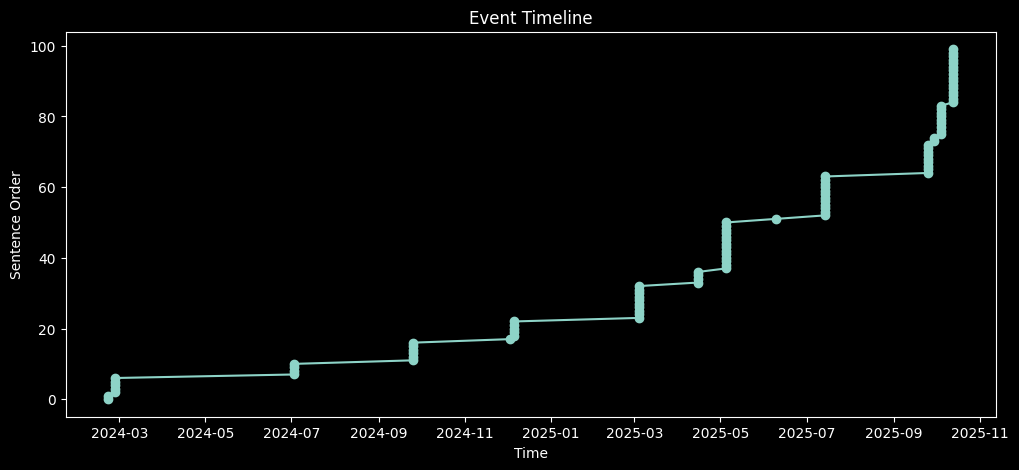

In [23]:
plt.figure(figsize=(12,5))

plt.plot(
    episode_df['published_date'],
    range(len(episode_df)),
    marker='o'
)

plt.title("Event Timeline")
plt.xlabel("Time")
plt.ylabel("Sentence Order")

plt.show()

## Event Clustering

In [24]:
import hdbscan

In [25]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=4,
    metric='euclidean'
)

event_labels = clusterer.fit_predict(episode_embeddings)

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [26]:
episode_df["event_id"] = event_labels
episode_df.head()

,orig_index,content_id,sentence,published_date,category,episode,event_id
0,107,1289436,"Meanwhile, Fahmi said that for instance, he ha...",2024-02-22,5G,19,-1
1,1146,1289431,Malaysia has recorded almost million 5G servic...,2024-02-22,5G,19,-1
2,472,1292744,"""This is a good achievement but we are all awa...",2024-02-27,5G,19,0
3,471,1292744,"Meanwhile, Fahmi when met said that he had als...",2024-02-27,5G,19,-1
4,462,1292744,Malaysia has proven to the world that the appr...,2024-02-27,5G,19,0


In [27]:
print("Number of events detected:", len(set(event_labels)) - (1 if -1 in event_labels else 0))
print(episode_df["event_id"].value_counts())

Number of events detected: 3
-1    66
 0    15
 1    12
 2     7
Name: event_id, dtype: int64


In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

reduced_embeddings = pca.fit_transform(episode_embeddings)

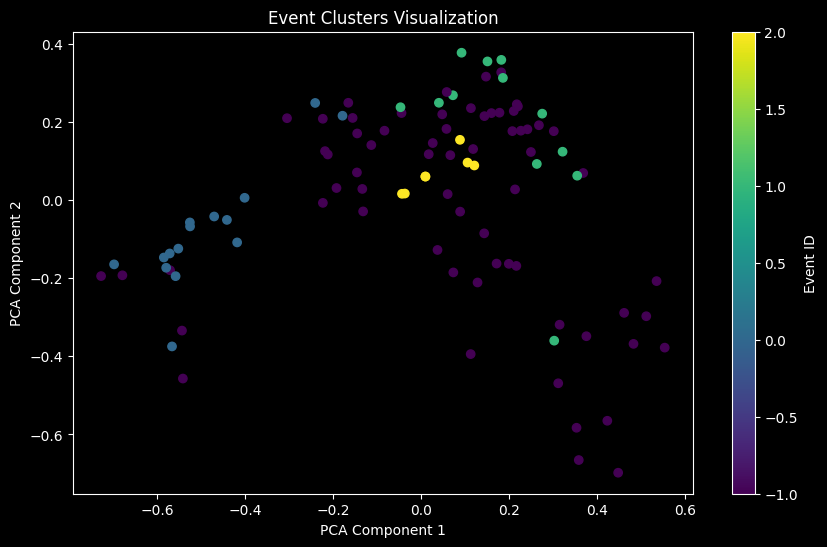

In [29]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    reduced_embeddings[:,0],
    reduced_embeddings[:,1],
    c=episode_df["event_id"],
)

plt.title("Event Clusters Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.colorbar(scatter, label="Event ID")

plt.show()

## Event Labelling

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [31]:
def generate_event_tag(sentence):

    vectorizer = TfidfVectorizer(stop_words='english', max_features=8)
    
    X = vectorizer.fit_transform([sentence])
    
    keywords = vectorizer.get_feature_names_out()

    tag = " ".join(keywords)

    return tag

In [32]:
from sklearn.metrics.pairwise import cosine_similarity

In [33]:
episode_df["event_tag"] = ""

for event in episode_df["event_id"].unique():

    if event == -1:
        continue

    cluster = episode_df[episode_df["event_id"] == event]

    cluster_embeddings = episode_embeddings[cluster.index]

    centroid = cluster_embeddings.mean(axis=0)

    similarities = cosine_similarity([centroid], cluster_embeddings)[0]
    central_index = similarities.argmax()

    rep_sentence = cluster.iloc[central_index]["sentence"]
    
    print(f"\n==========Event {event}==========")
    print(f'"{rep_sentence}"\n')
    print("Similarity:", similarities.max())
    print(f"===========================")

    tag = generate_event_tag(rep_sentence)

    episode_df.loc[episode_df["event_id"] == event, "event_tag"] = tag


==========Event 0==========
"Communications Minister Fahmi Fadzil on Sept 17 said Malaysia has achieved 5G coverage in populated areas across the country where a total of 7,191 5G sites have been developed nationwide, adding that the government is committed towards expanding access."

Similarity: 0.9065703654849611

==========Event 1==========
"That’s why Tan believes the rollout of 5G could unlock new possibilities especially when it comes to real-time data, automation, and large-scale monitoring."

Similarity: 0.8985983783419577

==========Event 2==========
"For 5G-enabled healthcare to flourish in Malaysia, Lin says there is a need to improve infrastructure from end to end."

Similarity: 0.9482170463644186


In [34]:
for event in sorted(episode_df["event_id"].unique()):
    
    if event == -1:
        continue

    min_date = episode_df[episode_df["event_id"] == event]["published_date"].min().strftime("%d-%m-%Y")
    max_date = episode_df[episode_df["event_id"] == event]["published_date"].max().strftime("%d-%m-%Y")
    
    print("\n========================================================================================")
    print("Event ID:", event, "  {", episode_df.event_tag.unique()[event+1],"}")
    print(f"Timeline: {min_date if min_date == max_date else f'{min_date} to {max_date}'}")
    print("========================================================================================")

    event_sentences = episode_df[episode_df["event_id"] == event]["sentence"].head(3)
    episode_df[episode_df["event_id"] == event].to_csv(fr"dataset\notFineTuned\events\balanced\eventID-{event}.csv",index=False)

    for s in event_sentences:
        print("-", s)


Event ID: 0   { 17 5g malaysia minister nationwide populated said sept }
Timeline: 27-02-2024 to 04-03-2025
- "This is a good achievement but we are all aware that in Malaysia we have some challenges with 5G of the areas we need to prioritise is in buildings
- Malaysia has proven to the world that the approach it has taken to build a 5G network is successful after emerging at the top spot globally in the 5G consistency score.
- The 5G coverage in populated areas in the country has now reached with 7,114 5G sites established nationwide so far, the Dewan Rakyat was told today (July 3).

Event ID: 1   { 5g automation believes comes data especially large monitoring }
Timeline: 05-05-2025 to 13-10-2025
- Enabling precision farming This comes across in three different use cases for the company’s 5G-enabled drones, including precision pesticide spraying, equipment monitoring, and security surveillance.
- The role played by 5G in this scenario comes largely in two areas.
- He says with faster

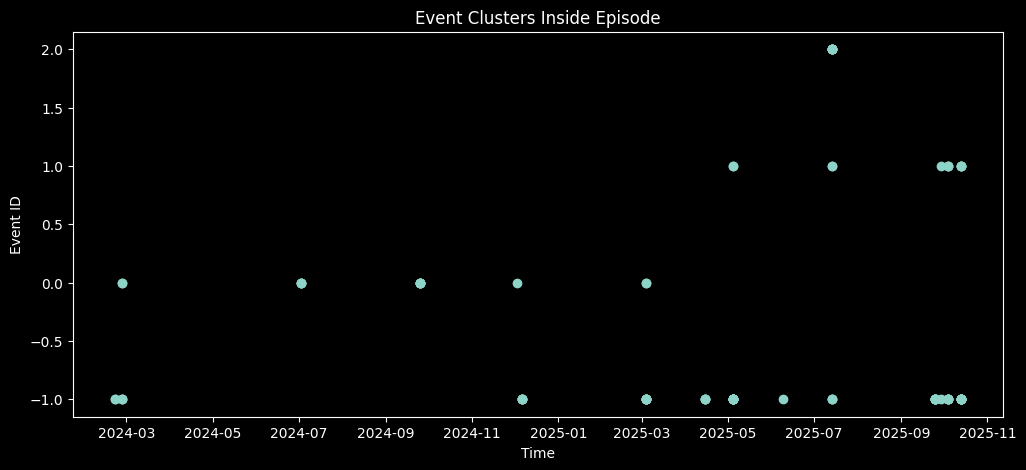

In [35]:
plt.figure(figsize=(12,5))

plt.scatter(
    episode_df["published_date"],
    episode_df["event_id"]
)

plt.xlabel("Time")
plt.ylabel("Event ID")
plt.title("Event Clusters Inside Episode")

plt.show()